#Task 2: Predict Future Stock Prices (Short-Term)

## Objective
The objective of this task is to use historical stock market data to predict the
next day’s closing price using machine learning techniques.

##Import and Install Libraries

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##Load Dataset

In [3]:
# Download stock data
stock = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

# View first rows
stock.head()

/tmp/ipython-input-2288826525.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503731,37.724594,36.627408,36.784150,148158800
2019-01-03,33.768082,34.606406,33.722959,34.193179,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131237,35.344976,34.649142,35.314102,219111200
2019-01-08,35.800953,36.055064,35.271361,35.518344,164101200


##Data Inspection

In [4]:
stock.info()
stock.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,120.318820,121.578787,118.920671,120.196258,1.015917e+08
std,46.336964,46.742382,45.903647,46.320527,5.261045e+07
min,33.768082,34.606406,33.722959,34.193179,2.404830e+07
25%,74.615812,75.236273,73.550218,74.207649,6.803012e+07
50%,131.293938,132.726030,129.931656,131.642307,8.861740e+07
75%,156.586288,159.196836,154.440785,156.923885,1.189786e+08
max,196.073105,197.567574,194.974504,195.984034,4.265100e+08


##Feature Engineering (Next-Day Prediction)

In [5]:
# Create target column
stock["Next_Close"] = stock["Close"].shift(-1)

# Drop last row (NaN target)
stock.dropna(inplace=True)

Split Features and Target

In [7]:
X = stock[["Open", "High", "Low", "Volume"]]
y = stock["Next_Close"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

##Train Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Make Predictions
y_pred = model.predict(X_test)

###Model Evaluation

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)


MAE: 1.776646869575029
MSE: 5.412587894839274
R² Score: 0.9825884489091954


##Plot Actual vs Predicted Closing Prices

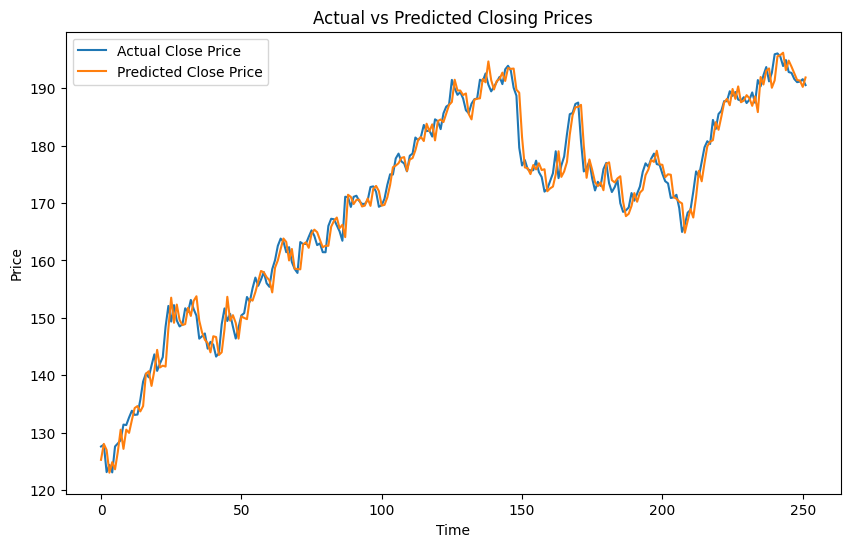

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label="Actual Close Price")
plt.plot(y_pred, label="Predicted Close Price")
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


## Results and Insights

The Linear Regression model was trained using Open, High, Low, and Volume features
to predict the next day’s closing price.

The predicted values closely follow the actual closing prices, indicating that
the model captures short-term price trends. However, small deviations exist due
to market volatility.

This approach is suitable for short-term prediction but may not fully capture
sudden market movements.
